### Rayleigh Sensitivity Kernel

In [1]:
# Import necessary dependencies
import sys
import pickle
import numpy as np

import matplotlib.pyplot as plt
from disba import PhaseSensitivity

sys.path.append('..')
from src.inv import animate_sensitivity_kernels

#### 1. Load Inversion Results

In [2]:
# Load the saved 2D matrix and metadata
saved_data = np.load("../results/inv_outputs/final_2D_matrix.npz")
vs_2d_matrix_mean = saved_data["vs_matrix_mean"]
vs_2d_matrix_best = saved_data["vs_matrix_best"]
positions = saved_data["positions"]
z_grid = saved_data["z_grid"]

# Load the entire list of InversionResults objects back into memory
with open("../results/inv_outputs/all_results_list.pkl", "rb") as f:
    all_results = pickle.load(f)

In [3]:
# Pick a column in the middle of 2D profile to test
middle_idx = len(positions) // 2
position_m = positions[middle_idx]
print(f"Testing sensitivity for position: {position_m:.2f} m")

# Extract the 1D shear wave velocity profile (in m/s)
vs_1d_ms = vs_2d_matrix_best[:, middle_idx]

Testing sensitivity for position: 571.00 m


#### 2. Convert to Disba's format (Thickness, Vp, Vs, Rho in km and km/s)

In [4]:
# 1. Calculate layer thicknesses from z_grid
z_depths = np.abs(z_grid)  # Ensure depths are positive
thickness_m = np.diff(z_depths)  
thickness_m = np.append(thickness_m, 10) # Append a dummpy 10m thickness for the bottom half-space

# 2. Convert to km
thickness_km = thickness_m / 1000.0
vs_kms = vs_1d_ms / 1000.0

# 3. Estimate Vp (for near surface) and density
vp_kms = vs_kms * 2.0
rho_gcm3 = np.full_like(vs_kms, 1.0)  # Matches inversion assumption

# Stack into the 4-column matrix: [thickness, vp, vs, density]
velocity_model = np.column_stack((thickness_km, vp_kms, vs_kms, rho_gcm3))

#### 3. Calculate the sensitivity kernels

In [5]:
# Initialize the calculator with our specified velocity model
ps = PhaseSensitivity(*velocity_model.T)

# Pick the frequencies we want to test (from dispersion images)
test_frequencies = [2.0, 3.0, 4.0, 5.0, 6.0]

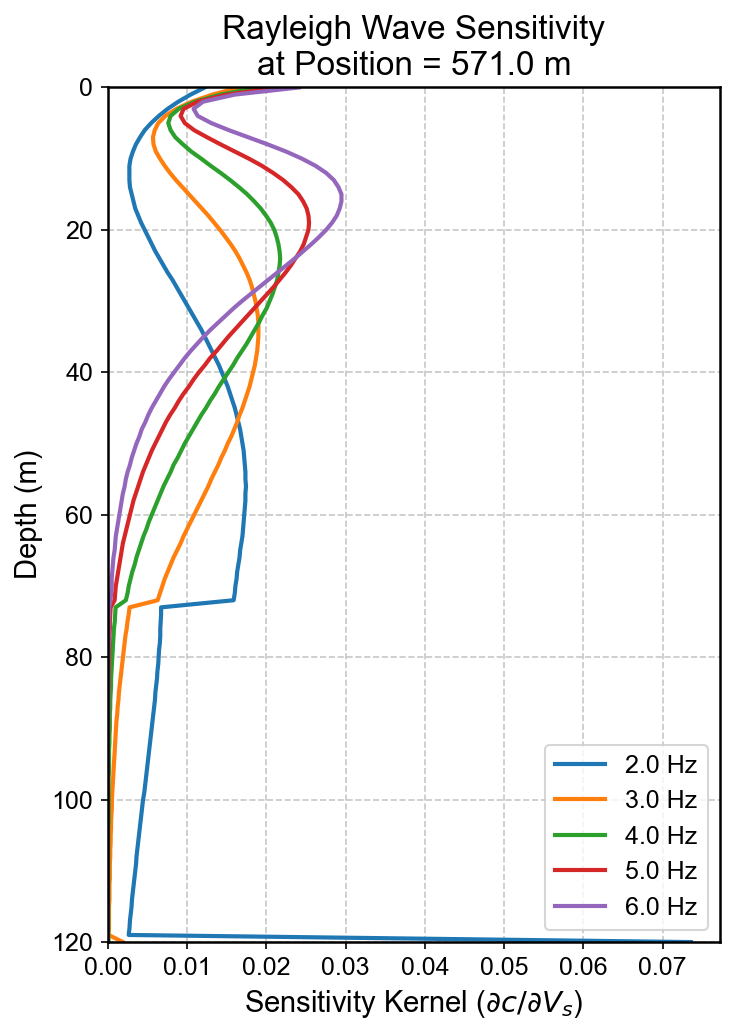

In [6]:
plt.figure(figsize=(5, 7))

for f in test_frequencies:
    # Disba requires Period (T = 1/f)
    period = 1.0 / f

    # Calculate fundamental mode (mode=0) Rayleigh wave sensitivity kernels to Vs
    k = ps(period, mode=0, wave="rayleigh", parameter="velocity_s")

    # Convert depth back to meters for plotting
    depth_m = k.depth * 1000.0

    plt.plot(k.kernel, depth_m, label=f"{f} Hz", linewidth=2)

plt.ylim(np.max(z_depths), 0) 
plt.xlim(left=0) # Kernels should start at or near zero

plt.xlabel("Sensitivity Kernel (${\partial c}/{\partial V_s}$)", fontsize=14)
plt.ylabel("Depth (m)", fontsize=14)
plt.title(f"Rayleigh Wave Sensitivity\nat Position = {position_m:.1f} m", fontsize=16)

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc="lower right", fontsize=12)
plt.tight_layout()

plt.show()

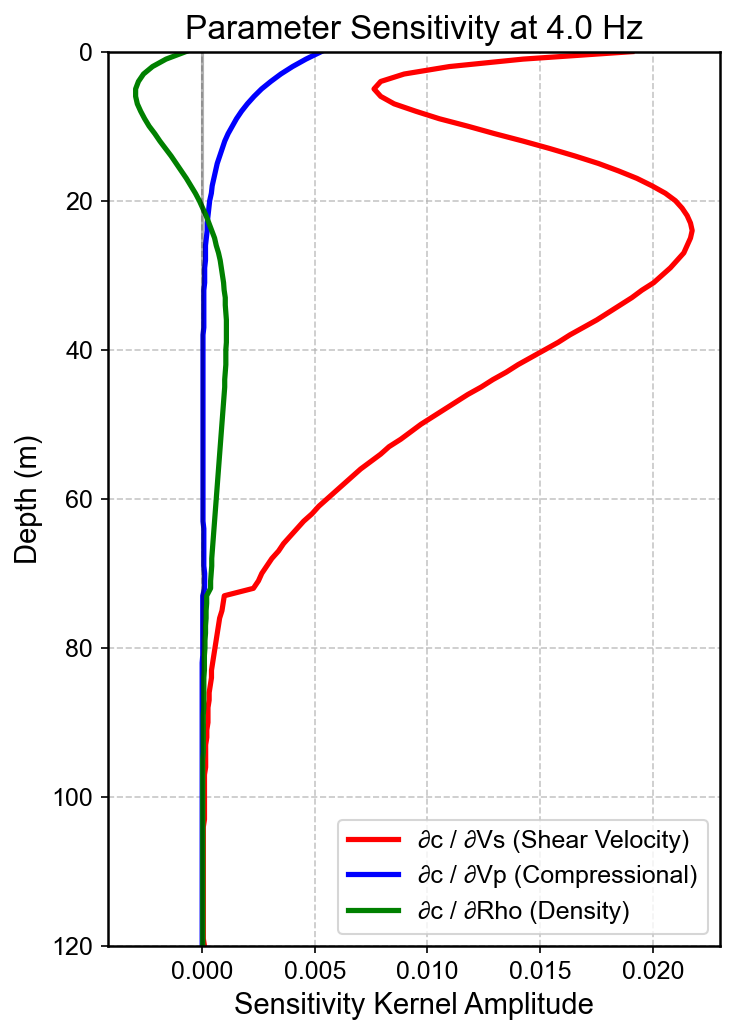

In [7]:
# Pick one frequency from your usable DAS range (e.g., 4.0 Hz)
f_test = 4.0 
period = 1.0 / f_test

plt.figure(figsize=(5, 7))

# Loop through ALL FOUR parameters
parameters_to_test = {
    "velocity_s": ("Vs (Shear Velocity)", "red"),
    "velocity_p": ("Vp (Compressional)", "blue"),
    "density": ("Rho (Density)", "green"),
    #"thickness": ("Thickness (d)", "purple")  
}

for param, (label, color) in parameters_to_test.items():
    # Calculate the kernel for each parameter
    k = ps(period, mode=0, wave="rayleigh", parameter=param)
    depth_m = k.depth * 1000.0 
    
    plt.plot(k.kernel, depth_m, label=f"∂c / ∂{label}", color=color, linewidth=2.5)

plt.ylim(120, 0)
plt.axvline(0, color='black', linestyle='-', alpha=0.3) # Draw a line at zero

plt.xlabel("Sensitivity Kernel Amplitude", fontsize=14)
plt.ylabel("Depth (m)", fontsize=14)
plt.title(f"Parameter Sensitivity at {f_test} Hz", fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc="lower right", fontsize=12)
plt.tight_layout()

plt.show()

In [8]:
animate_sensitivity_kernels(positions, vs_2d_matrix_best, z_grid, x_max=0.05)